### Importación de Librerías

In [2]:
import pandas as pd
import numpy as np
import openpyxl

# Encuentra 24 v json

In [34]:
import json
with open("encuentra24 (1).json", "r", encoding="utf-8") as f:
    datos = json.load(f)

In [43]:
df_encuentra = pd.DataFrame(datos)
print(df_encuentra.shape)
df_encuentra.info()

(810, 20)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 810 entries, 0 to 809
Data columns (total 20 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   lid     810 non-null    object 
 1   tit     810 non-null    object 
 2   dat     810 non-null    object 
 3   lat     810 non-null    float64
 4   lng     810 non-null    float64
 5   img     810 non-null    object 
 6   fea     810 non-null    bool   
 7   feg     810 non-null    bool   
 8   fep     810 non-null    bool   
 9   fes     810 non-null    bool   
 10  pri     810 non-null    object 
 11  ren     810 non-null    object 
 12  sqm     810 non-null    object 
 13  rom     810 non-null    object 
 14  prk     810 non-null    object 
 15  bth     810 non-null    object 
 16  des     810 non-null    object 
 17  lin     810 non-null    object 
 18  biurl   810 non-null    object 
 19  exct    810 non-null    bool   
dtypes: bool(5), float64(2), object(13)
memory usage: 99.0+ KB


In [44]:
df_encuentra.lid.nunique()

810

In [37]:
df_encuentra.head()

,lid,tit,dat,lat,lng,img,fea,feg,fep,fes,pri,ren,sqm,rom,prk,bth,des,lin,biurl,exct
0,31299387,ALQUILO CASA EN SAN SALVADOR COL. ATLACAT ...,18/09/2025,13.715,-89.180,https://photos.encuentra24.com/t_or_cvr_s/f_au...,False,False,True,False,,$700.00,,3,1,2,ALQUILO CASA EN SAN SALVADOR COL. ATLACAT (PAS...,/el-salvador-es/bienes-raices-alquiler-casas/a...,https://www.encuentra24.com/clickhouse_mvp.php...,True
1,30873413,": Casa en Venta - Avenida Bernal ¡Amplia, ...",13/09/2025,13.720,-89.217,https://photos.encuentra24.com/t_or_cvr_s/f_au...,False,False,True,False,"$265,000",,223,4,2,2.5,"CASA EN VENTA – AVENIDA BERNAL, COLONIA SATÉLI...",/el-salvador-es/bienes-raices-venta-de-propied...,https://www.encuentra24.com/clickhouse_mvp.php...,True
2,30640818,Apartamento con TERRAZA/JARDIN PRIVADO - ...,12/09/2025,13.695,-89.213,https://photos.encuentra24.com/t_or_cvr_s/f_au...,False,False,True,False,"$299,900",,170,3,2,3,Sin intermediarios. Apartamento en venta ubica...,/el-salvador-es/bienes-raices-venta-de-propied...,https://www.encuentra24.com/clickhouse_mvp.php...,True
3,31029265,"$275,000 Inmueble con gran demanda para ...",18/09/2025,13.707,-89.220,https://photos.encuentra24.com/t_or_cvr_s/f_au...,False,False,True,False,"$275,000",,180,6,8,4,Construccion moderna en terreno de 198.42M2 eq...,/el-salvador-es/bienes-raices-venta-de-propied...,https://www.encuentra24.com/clickhouse_mvp.php...,True
4,31025870,Res lomas de San Francisco avenida 2,12/09/2025,13.695,-89.213,https://photos.encuentra24.com/t_or_cvr_s/f_au...,False,False,True,False,"$475,000",,358,3,4,5,"Cochera cuatro vehículos, baños social, vestí...",/el-salvador-es/bienes-raices-venta-de-propied...,https://www.encuentra24.com/clickhouse_mvp.php...,True


In [38]:
df_encuentra.dat.nunique()

238

In [45]:
df_encuentra['ren'].replace("", np.nan, inplace=True)
df_encuentra['pri'].replace("", np.nan, inplace=True)


/tmp/ipython-input-3746842164.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_encuentra['ren'].replace("", np.nan, inplace=True)
/tmp/ipython-input-3746842164.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', t

In [48]:
#Exploración Encuentra 24
#Se ponen las columnas con strings en mayúsculas
str_cols = df_encuentra.select_dtypes(include=['object']).columns
df_encuentra[str_cols] = df_encuentra[str_cols].apply(lambda x: x.str.upper())

#Quitamos propiedades en renta con el campo ren, se dejan los que tienen nulo este campo
df_encuentra_final = df_encuentra[df_encuentra['ren'].isnull()] #Acá nos quedamos con 1829 datos
print('BD sin rentas: ', df_encuentra_final.shape)

#Se eliminan las filas que en tit contentan la palabra lote o terreno
palabras_terr = ['LOTE', 'TERRENO', 'LOCAL', 'FINCA']
df_encuentra_final = df_encuentra_final[~df_encuentra_final['tit'].str.contains("|".join(palabras_terr), case=False, na=False)] #Acá nos quedamos con 2425 datos
print('BD sin terrenos: ', df_encuentra_final.shape)


#Se eliminan las filas que tengan nulo el campo rom o bth, se dejan los que no tienen nulo este campo
df_encuentra_final = df_encuentra_final.dropna(subset = ['rom','bth']) #Acá nos quedamos con 1091 datos
print('BD sin cuartos/banos: ', df_encuentra_final.shape)

#Se crea columna categórica para identificar el tipo de propiedad
# Condiciones
condiciones = [
    df_encuentra_final["des"].str.contains("CASA", case=False, na=False)|df_encuentra_final["tit"].str.contains("CASA", case=False, na=False),
    df_encuentra_final["des"].str.contains("APARTAMENTO|DEPARTAMENTO", case=False, na=False)|df_encuentra_final["tit"].str.contains("APARTAMENTO|DEPARTAMENTO", case=False, na=False)
]

# Valores que se asignan
valores = ["CASA", "APARTAMENTO"]

# Crear nueva columna categórica
df_encuentra_final["tipo_vivienda"] = np.select(condiciones, valores, default="OTRO")

#Se eliminan los que se categorizaron como "OTRO"
#df_encuentra_final = df_encuentra_final[df_encuentra_final['tipo_vivienda']!="OTRO"] #Acá nos quedamos con 995 datos
#print('BD sin otros: ', df_encuentra_final.shape)

#Se eliminan los duplicados de la columna lid
df_encuentra_final.drop_duplicates(subset = ['lid'], inplace = True) #Acá nos quedamos con 69 datos
print('BD sin dup: ', df_encuentra_final.shape)

#Se crea campo de fuente
df_encuentra_final["fuente"] = "ENCUENTRA24"

#Nos quedamos con las columnas importantes
df_encuentra_final = df_encuentra_final[['lid','dat','lat','lng','pri','sqm','rom','prk','bth','tipo_vivienda','fuente']]

df_encuentra_final.shape

BD sin rentas:  (646, 20)
BD sin terrenos:  (435, 20)
BD sin cuartos/banos:  (435, 20)
BD sin dup:  (435, 21)


(435, 11)

In [49]:
df_encuentra_final["pri"] = (
    df_encuentra_final["pri"]
      .str.replace("[$,]", "", regex=True)   # quita $ y ,
      .astype(float)                         # o int si todos son enteros
)

In [51]:
pd.set_option('display.float_format', lambda x: '%.3f' % x)
df_encuentra_final.pri.describe(percentiles = [0.01,0.025,0.05,0.075,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,0.95,0.99])

,pri
count,434.000
mean,607917.169
std,977147.518
min,4.000
1%,182.800
2.5%,5000.000
5%,27600.000
7.5%,50000.000
10%,60900.000
20%,125000.000


In [52]:
### Filtramos outliers bajos (altos no xq si hay casas de ese precio)

df_encuentra_final = df_encuentra_final[df_encuentra_final['pri']>=5000]
df_encuentra_final.shape

(424, 11)

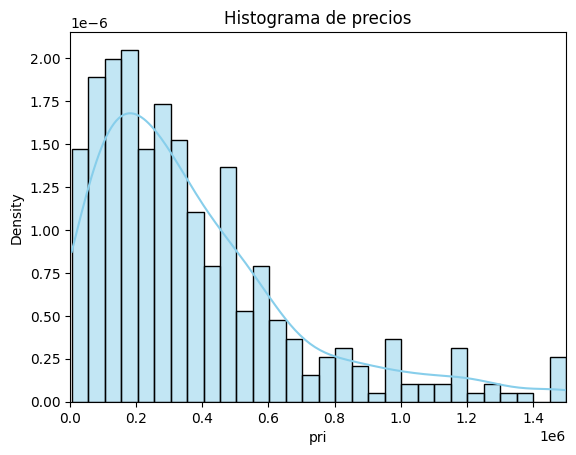

In [53]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
data = df_encuentra_final[df_encuentra_final['pri']<=1500000]
sns.histplot(data['pri'], bins=30, kde=True, color="skyblue", stat="density", edgecolor="black")

plt.xlim(-1, 1500000)  # muestra solo entre -2 y 2

plt.title("Histograma de precios")
plt.show()


### Exploración Encuentra 24

### Exploración Propi

In [55]:
df_propi = pd.read_json('propi-data.json')

In [56]:
df_propi.shape

(199, 23)

In [67]:
#Exploración Propi
#Se ponen las columnas con strings en mayúsculas
str_cols = df_propi.select_dtypes(include=['object']).columns
df_propi[str_cols] = df_propi[str_cols].apply(lambda x: x.str.upper())

#Quitamos propiedades en renta con el campo ren, se dejan los que tienen nulo este campo
# df_propi_final = df_propi[df_propi['ren'].isnull()] #No aplica porque todos los valores de este campo son cero

#Se eliminan las filas que en tit contentan la palabra lote o terreno
palabras_terr = ['LOTE', 'TERRENO', 'LOCAL', 'FINCA']
df_propi_final = df_propi[~df_propi['tit'].str.contains("|".join(palabras_terr), case=False, na=False)] #Acá nos quedamos con 194 datos
print(df_propi_final.shape)
# #Se eliminan las filas que tengan nulo el campo rom o bth, se dejan los que no tienen nulo este campo
#df_propi_final = df_propi_final.dropna(subset = ['rom','bth']) #Acá nos quedamos con 164 datos
print(df_propi_final.shape)
#Se crea columna categórica para identificar el tipo de propiedad
# Condiciones
condiciones = [
    df_propi_final["tit"].str.contains("CASA", case=False, na=False),
    df_propi_final["tit"].str.contains("APARTAMENTO|DEPARTAMENTO", case=False, na=False)
]

# Valores que se asignan
valores = ["CASA", "APARTAMENTO"]

# Crear nueva columna categórica
df_propi_final["tipo_vivienda"] = np.select(condiciones, valores, default="OTRO")
print(df_propi_final.shape)
#Se eliminan los que se categorizaron como "OTRO"
#df_propi_final = df_propi_final[df_propi_final['tipo_vivienda']!="OTRO"] #Acá no se eliminó ninguno
#print(df_propi_final.shape)
# #Se eliminan los duplicados de la columna lid
# df_encuentra_final.drop_duplicates(subset = ['lid'], inplace = True) #Este no aplica porque no tiene este campo

#Se crea un campo de id
df_propi_final["lid"] = range(len(df_propi_final))

#Se crea campo fuente
df_propi_final["fuente"] = "PROPI"

#Nos quedamos con las columnas importantes
df_propi_final = df_propi_final[['lid','dat','lat','lng','pri','sqm','rom','prk','bth','tipo_vivienda','fuente']]

df_propi_final.shape

(194, 23)
(194, 23)
(194, 24)


/tmp/ipython-input-115738979.py:27: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_propi_final["tipo_vivienda"] = np.select(condiciones, valores, default="OTRO")
/tmp/ipython-input-115738979.py:36: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_propi_final["lid"] = range(len(df_propi_final))
/tmp/ipython-input-115738979.py:39: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documen

(194, 11)

In [68]:
df_propi_final.head()

,lid,dat,lat,lng,pri,sqm,rom,prk,bth,tipo_vivienda,fuente
0,0,NaN,13.698,-89.242,658000.000,NaN,NaN,0,NaN,OTRO,PROPI
1,1,NaN,13.698,-89.241,697000.000,NaN,NaN,0,NaN,OTRO,PROPI
2,2,NaN,13.694,-89.241,830000.000,500.000,4.000,4,4.000,CASA,PROPI
3,3,NaN,13.704,-89.245,285000.000,133.000,3.000,2,3.000,APARTAMENTO,PROPI
4,4,NaN,13.693,-89.241,850000.000,453.000,5.000,2,3.000,CASA,PROPI


In [69]:
df_propi_final.info()

<class 'pandas.core.frame.DataFrame'>
Index: 194 entries, 0 to 198
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   lid            194 non-null    int64  
 1   dat            0 non-null      float64
 2   lat            194 non-null    float64
 3   lng            194 non-null    float64
 4   pri            194 non-null    float64
 5   sqm            164 non-null    float64
 6   rom            164 non-null    float64
 7   prk            194 non-null    int64  
 8   bth            164 non-null    float64
 9   tipo_vivienda  194 non-null    object 
 10  fuente         194 non-null    object 
dtypes: float64(7), int64(2), object(2)
memory usage: 18.2+ KB


In [70]:
df_propi_final.pri.describe(percentiles = [0.01,0.025,0.05,0.075,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,0.95,0.99])

,pri
count,194.000
mean,439402.666
std,292004.472
min,75000.000
1%,169018.180
2.5%,174594.000
5%,193100.500
7.5%,213897.500
10%,227461.040
20%,270000.000


In [ ]:
df_propi_final.to_excel("propi_final.xlsx")

### Exploración Remax

In [71]:
df_remax = pd.read_json('remax-data.json')

In [72]:
df_remax.shape

(197, 15)

In [74]:
#Exploración Remax
#Se ponen las columnas con strings en mayúsculas
str_cols = df_remax.select_dtypes(include=['object']).columns
df_remax[str_cols] = df_remax[str_cols].apply(lambda x: x.str.upper())

#Quitamos propiedades en renta con el campo ren, se dejan los que tienen nulo este campo
# df_remax_final = df_remax[df_remax['ren'].isnull()] #No aplica porque no tiene este campo

#Se eliminan las filas que en tit contentan la palabra lote o terreno
palabras_terr = ['LOTE', 'TERRENO', 'LOCAL', 'FINCA', 'OFICINA']
df_remax_final = df_remax[~df_remax['title'].str.contains("|".join(palabras_terr), case=False, na=False)] #Acá nos quedamos con 127 datos
print(df_remax_final.shape)
# #Se eliminan las filas que tengan nulo el campo rom o bth, se dejan los que no tienen nulo este campo
#df_remax_final = df_remax_final.dropna(subset = ['bedrooms','bathrooms']) #Acá nos quedamos con 87 datos
#print(df_remax_final.shape)
#Se eliminan las filas que en tit hagan referencia a un alquiler
palabras_alq = ['ALQUILO', 'ALQUILER']
df_remax_final = df_remax_final[~df_remax_final['title'].str.contains("|".join(palabras_alq), case=False, na=False)] #Acá nos quedamos con 65 datos
df_remax_final = df_remax_final[~df_remax_final['description'].str.contains("|".join(palabras_alq), case=False, na=False)] #Acá nos quedamos con 65 datos
print(df_remax_final.shape)
#Se crea columna categórica para identificar el tipo de propiedad
# Condiciones
condiciones = [
    df_remax_final["description"].str.contains("CASA", case=False, na=False)|df_remax_final["title"].str.contains("CASA", case=False, na=False),
    df_remax_final["description"].str.contains("APARTAMENTO|DEPARTAMENTO", case=False, na=False)|df_remax_final["title"].str.contains("APARTAMENTO|DEPARTAMENTO", case=False, na=False)
]

# Valores que se asignan
valores = ["CASA", "APARTAMENTO"]

# Crear nueva columna categórica
df_remax_final["tipo_vivienda"] = np.select(condiciones, valores, default="OTRO")

#Se eliminan los que se categorizaron como "OTRO"
#df_remax_final = df_remax_final[df_remax_final['tipo_vivienda']!="OTRO"] #Acá nos quedamos con 50 datos
#print(df_remax_final.shape)
#Se eliminan los duplicados de la columna lid
df_remax_final.drop_duplicates(subset = ['id'], inplace = True) #Seguimos con 50 datos

#Se crea campo fuente
df_remax_final["fuente"] = "REMAX"

#Se cambia el nombre de los campos para que coincidan
df_remax_final = df_remax_final.rename(columns={'id':'lid','price':'pri','bedrooms':'rom','parking':'prk','bathrooms':'bth'})

# Se agregan las columnas que no tiene
df_remax_final['Localización'] = np.nan
df_remax_final['Publicado'] = np.nan
df_remax_final['Precio/M² de terreno'] = np.nan
df_remax_final['dat'] = np.nan
df_remax_final['lat'] = np.nan
df_remax_final['lng'] = np.nan
df_remax_final['sqm'] = np.nan

#Nos quedamos con las columnas importantes
df_remax_final = df_remax_final[['lid','dat','lat','lng','pri','sqm','rom','prk','bth','Localización','Publicado','Precio/M² de terreno','tipo_vivienda','fuente']]

df_remax_final.shape

(127, 15)
(99, 15)


(81, 14)

In [75]:
df_remax_final.head()

,lid,dat,lat,lng,pri,sqm,rom,prk,bth,Localización,Publicado,Precio/M² de terreno,tipo_vivienda,fuente
0,V20-004236,NaN,NaN,NaN,"$579,622",NaN,2.000,NaN,2.000,NaN,NaN,NaN,OTRO,REMAX
1,V20-003725,NaN,NaN,NaN,"$519,390",NaN,2.000,NaN,1.000,NaN,NaN,NaN,OTRO,REMAX
2,V07-004812,NaN,NaN,NaN,"$250,000",NaN,NaN,NaN,2.000,NaN,NaN,NaN,CASA,REMAX
5,V07-004736,NaN,NaN,NaN,"$305,000",NaN,2.000,2.000,1.000,NaN,NaN,NaN,CASA,REMAX
14,V07-004762,NaN,NaN,NaN,"$350,000",NaN,2.000,2.000,1.000,NaN,NaN,NaN,CASA,REMAX


In [77]:
df_remax_final["pri"] = (
    df_remax_final["pri"]
      .str.replace("[$,]", "", regex=True)   # quita $ y ,
      .astype(float)                         # o int si todos son enteros
)
df_remax_final.pri.describe(percentiles = [0.01,0.025,0.05,0.075,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,0.95,0.99])

,pri
count,80.000
mean,456288.037
std,545047.094
min,9.000
1%,9.000
2.5%,12.900
5%,2560.000
7.5%,55965.000
10%,70000.000
20%,118000.000


In [76]:
df_remax_final.info()

<class 'pandas.core.frame.DataFrame'>
Index: 81 entries, 0 to 178
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   lid                   80 non-null     object 
 1   dat                   0 non-null      float64
 2   lat                   0 non-null      float64
 3   lng                   0 non-null      float64
 4   pri                   80 non-null     object 
 5   sqm                   0 non-null      float64
 6   rom                   66 non-null     float64
 7   prk                   61 non-null     float64
 8   bth                   69 non-null     float64
 9   Localización          0 non-null      float64
 10  Publicado             0 non-null      float64
 11  Precio/M² de terreno  0 non-null      float64
 12  tipo_vivienda         81 non-null     object 
 13  fuente                81 non-null     object 
dtypes: float64(10), object(4)
memory usage: 9.5+ KB


In [ ]:
df_remax_final.to_excel("remax_final.xlsx")

### Exploración Vivo

In [78]:
df_vivo = pd.read_json('vivo-data.json')

In [79]:
df_vivo.shape

(576, 23)

In [80]:
#Exploración Vivo
#Se ponen las columnas con strings en mayúsculas
str_cols = df_vivo.select_dtypes(include=['object']).columns
df_vivo[str_cols] = df_vivo[str_cols].apply(lambda x: x.str.upper())

#Quitamos propiedades en renta con el campo ren, se dejan los que tienen nulo este campo
# df_vivo_final = df_vivo[df_vivo['ren'].isnull()] #No aplica porque todos los valores de este campo son cero

#Se eliminan las filas que en tit contentan la palabra lote o terreno
palabras_terr = ['LOTE', 'TERRENO', 'LOCAL', 'FINCA']
df_vivo_final = df_vivo[~df_vivo['tit'].str.contains("|".join(palabras_terr), case=False, na=False)] #Acá nos quedamos con 378 datos
print(df_vivo_final.shape)

#Se eliminan las filas que tengan nulo el campo rom o bth, se dejan los que no tienen nulo este campo
#df_vivo_final = df_vivo_final.dropna(subset = ['rom','bth']) #Acá nos quedamos con 251 datos
#print(df_vivo_final.shape)

#Se eliminan los registros que tienen la columna pri con valores nulos
df_vivo_final = df_vivo_final.dropna(subset = "pri") #Acá mos quedamos con 99 datos
print(df_vivo_final.shape)

#Se crea columna categórica para identificar el tipo de propiedad
# Condiciones
condiciones = [
    df_vivo_final["tit"].str.contains("CASA", case=False, na=False),
    df_vivo_final["tit"].str.contains("APARTAMENTO|DEPARTAMENTO", case=False, na=False)
]

# Valores que se asignan
valores = ["CASA", "APARTAMENTO"]

# Crear nueva columna categórica
df_vivo_final["tipo_vivienda"] = np.select(condiciones, valores, default="OTRO")

#Se eliminan los que se categorizaron como "OTRO"
#df_vivo_final = df_vivo_final[df_vivo_final['tipo_vivienda']!="OTRO"] #Acá nos quedamos con 92 datos

#Se eliminan las filas que en tit hagan referencia a un alquiler
palabras_alq = ['ALQUILO', 'ALQUILER']
df_vivo_final = df_vivo_final[~df_vivo_final['tit'].str.contains("|".join(palabras_alq), case=False, na=False)] #Acá nos quedamos con 0 datos porque todos son alquileres
print(df_vivo_final.shape)
# # #Se eliminan los duplicados de la columna lid
# # df_vivo_final.drop_duplicates(subset = ['lid'], inplace = True) #Este no aplica porque no tiene este campo

# #Se crea campo fuente
# df_vivo_final["fuente"] = "VIVO"

# #Nos quedamos con las columnas importantes
# df_vivo_final = df_vivo_final[['lid','dat','lat','lng','pri','sqm','rom','prk','bth','Localización','Publicado','Precio/M² de terreno','tipo_vivienda','fuente']]

df_vivo_final.shape

(378, 23)
(183, 23)
(0, 24)


(0, 24)

In [ ]:
df_vivo_final.to_excel("vivo_final.xlsx")

### Consolidación de datos

In [33]:
df_remax_final.shape

(50, 14)

In [85]:
df_final = pd.concat([df_encuentra_final,df_propi_final,df_remax_final], ignore_index = True)

In [86]:
print(df_final.shape)
df_final.head()

(699, 14)


,lid,dat,lat,lng,pri,sqm,rom,prk,bth,tipo_vivienda,fuente,Localización,Publicado,Precio/M² de terreno
0,30873413,13/09/2025,13.720,-89.217,265000.000,223,4,2,2.5,CASA,ENCUENTRA24,NaN,NaN,NaN
1,30640818,12/09/2025,13.695,-89.213,299900.000,170,3,2,3,APARTAMENTO,ENCUENTRA24,NaN,NaN,NaN
2,31029265,18/09/2025,13.707,-89.220,275000.000,180,6,8,4,OTRO,ENCUENTRA24,NaN,NaN,NaN
3,31025870,12/09/2025,13.695,-89.213,475000.000,358,3,4,5,OTRO,ENCUENTRA24,NaN,NaN,NaN
4,31324136,13/09/2025,13.855,-88.972,850000.000,2700,,40,7,OTRO,ENCUENTRA24,NaN,NaN,NaN


In [90]:
df_final = df_final[df_final['pri']>=5000]
df_final.shape

(693, 14)

In [91]:
df_final['fuente'].value_counts()

,count
fuente,
ENCUENTRA24,424
PROPI,194
REMAX,75


In [92]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
Index: 693 entries, 0 to 697
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   lid                   693 non-null    object 
 1   dat                   424 non-null    object 
 2   lat                   618 non-null    float64
 3   lng                   618 non-null    float64
 4   pri                   693 non-null    float64
 5   sqm                   588 non-null    object 
 6   rom                   653 non-null    object 
 7   prk                   676 non-null    object 
 8   bth                   655 non-null    object 
 9   tipo_vivienda         693 non-null    object 
 10  fuente                693 non-null    object 
 11  Localización          0 non-null      float64
 12  Publicado             0 non-null      float64
 13  Precio/M² de terreno  0 non-null      float64
dtypes: float64(6), object(8)
memory usage: 81.2+ KB


In [93]:
df_final.pri.describe(percentiles = [0.01,0.025,0.05,0.075,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,0.95,0.99])

,pri
count,693.000
mean,556384.674
std,809388.930
min,5000.000
1%,19840.000
2.5%,40000.000
5%,60000.000
7.5%,75000.000
10%,99200.000
20%,170000.000


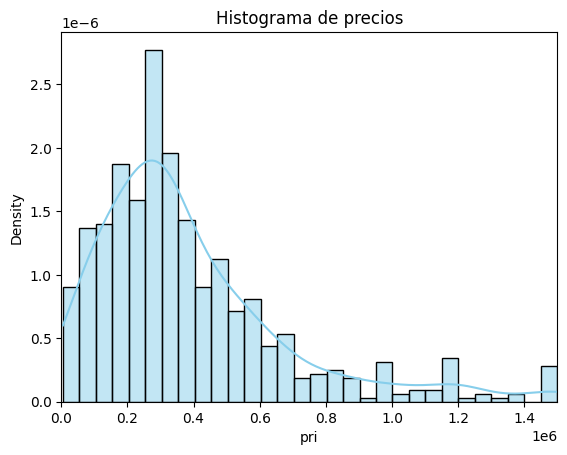

In [94]:
data = df_final[df_final['pri']<=1500000]
sns.histplot(data['pri'], bins=30, kde=True, color="skyblue", stat="density", edgecolor="black")

plt.xlim(-1, 1500000)  # muestra solo entre -2 y 2

plt.title("Histograma de precios")
plt.show()

In [95]:
df_final.to_excel("datos_final.xlsx")